# Tutorial 3e: OpticalSystemModule - You Own the Loop


When you need a custom loss function, batched data, or want to compose an optic into a
larger ML model, use `OpticalSystemModule` and own the optimization loop yourself.

`OpticalSystemModule` wraps an `Optic` + `OptimizationProblem` as a `torch.nn.Module`,
exposing the optical parameters as learnable tensors.  You call any PyTorch optimizer
directly on the module. Optiland never touches the loop.

Topics covered:

- The loop-ownership rule: `minimize()` vs `OpticalSystemModule`
- Basic Adam training loop on a singlet
- Plotting convergence
- Custom objective functions
- The forward-pass mutation contract
- GPU usage notes


## 1. The loop-ownership rule

| Approach | Who runs the loop? | When to use |
|----------|--------------------|-------------|
| `minimize(problem, method)` | Optiland | Standard lens optimization; you want a clean `OptimizationResult` |
| `OpticalSystemModule` | You | Custom loss, batched objectives, PyTorch scheduler, mixed ML+optics |

See Tutorial 3b for the full `minimize()` API.  This tutorial focuses exclusively on
`OpticalSystemModule`.

> **Backend requirement**: `OpticalSystemModule` requires the PyTorch backend.  Call
> `be.set_backend('torch')` before building the lens.


## 2. Setup - build a singlet and switch to the PyTorch backend


Lens ready. Backend: torch
Starting lens snapshotted.


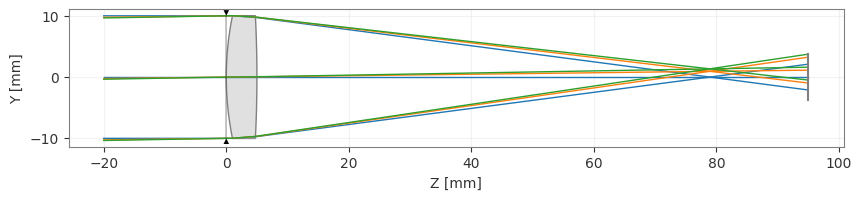

In [1]:
import copy

import numpy as np
import torch
import matplotlib.pyplot as plt

import optiland.backend as be
from optiland import optic
from optiland.optimization import OptimizationProblem
from optiland.ml import OpticalSystemModule

# Switch to the differentiable PyTorch backend
be.set_backend('torch')

lens = optic.Optic()
lens.surfaces.add(index=0, thickness=np.inf)
lens.surfaces.add(index=1, thickness=5.0, radius=50.0, material='N-BK7', is_stop=True)
lens.surfaces.add(index=2, thickness=90.0, radius=-200.0)
lens.surfaces.add(index=3)
lens.set_aperture(aperture_type='EPD', value=20)
lens.fields.set_type('angle')
lens.fields.add(y=0.0)
lens.fields.add(y=0.7)
lens.fields.add(y=1.0)
lens.wavelengths.add(value=0.4861)
lens.wavelengths.add(value=0.5876, is_primary=True)
lens.wavelengths.add(value=0.6563)

print('Lens ready. Backend:', be.get_backend())
_ = lens.draw()

# Snapshot the starting lens before problem.info() triggers grad-tracked
# ray tracing, which makes deep-copy unavailable on affected tensors.
lens_start = copy.deepcopy(lens)
print('Starting lens snapshotted.')

## 3. Define the optimization problem

The problem definition is identical to the `minimize()` workflow.  We will minimize RMS
spot size across all fields and constrain the effective focal length.

In [2]:
problem = OptimizationProblem()

for Hx, Hy in lens.fields.get_field_coords():
    input_data = {
        'optic': lens, 'surface_number': -1,
        'Hx': Hx, 'Hy': Hy,
        'num_rays': 5, 'wavelength': 0.5876,
        'distribution': 'hexapolar',
    }
    problem.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)

problem.add_operand('f2', target=100, weight=2, input_data={'optic': lens})

problem.add_variable(lens, 'radius', surface_number=1, min_val=-500, max_val=500)
problem.add_variable(lens, 'radius', surface_number=2, min_val=-500, max_val=500)
problem.add_variable(lens, 'thickness', surface_number=2, min_val=50, max_val=200)

problem.info()

C:\Users\kdani\AppData\Local\Temp\ipykernel_2656\3100248995.py:1: UserWarning: Gradient tracking is enabled for PyTorch.
  problem = OptimizationProblem()


╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                981.696 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   1.588 │   1.588 │           0.26 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   1.59  │   1.59  │           0.26 │
│  2 │ rms spot size  │        0 │              │              │        1 │             1 │   1

## 4. Basic usage: Adam training loop

`OpticalSystemModule(optic=..., problem=...)` exposes the problem variables as
`module.parameters()`, exactly like any `torch.nn.Module`.  Calling `module()` performs
a forward pass that:

1. Writes the current parameter tensors back into the `Optic`.
2. Evaluates the merit function.
3. Returns a scalar `torch.Tensor` suitable for `.backward()`.

In [3]:
module = OpticalSystemModule(optic=lens, problem=problem)
optimizer_torch = torch.optim.Adam(module.parameters(), lr=1e-2)

losses = []
for epoch in range(100):
    optimizer_torch.zero_grad()
    loss = module()          # forward(): evaluate merit
    loss.backward()          # autodiff through the ray trace
    optimizer_torch.step()
    losses.append(loss.item())

print(f'Initial merit: {losses[0]:.6f}')
print(f'Final merit:   {losses[-1]:.6f}')
print(f'Improvement:   {100 * (losses[0] - losses[-1]) / losses[0]:.1f}%')

Initial merit: 981.695862
Final merit:   0.188751
Improvement:   100.0%


## 5. Plot convergence


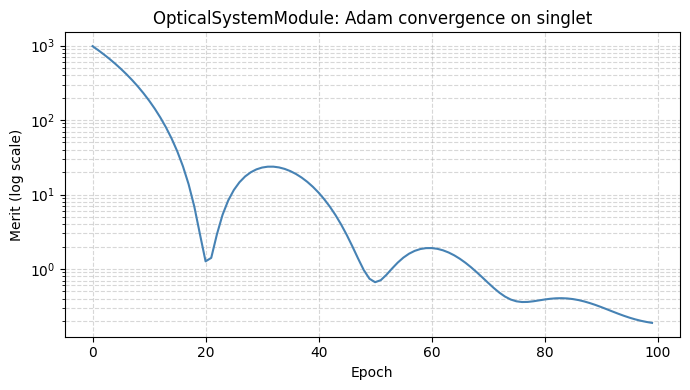

In [4]:
plt.figure(figsize=(7, 4))
plt.semilogy(losses, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Merit (log scale)')
plt.title('OpticalSystemModule: Adam convergence on singlet')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Custom objective function

By default, `module()` uses the merit function defined in `problem`.  You can override
this by passing an `objective_fn` callable to the constructor, or by replacing
`module.objective_fn` after construction.  The function must take **no arguments**.
It is called as `objective_fn()` on every forward pass.  Use a closure or a lambda
that captures the module or problem.

This is useful when you want to blend the optical merit with an external ML loss,
apply regularization, or define objectives that are not expressible as Optiland operands.

In [5]:
# Rebuild a fresh lens so the custom-objective example starts clean
lens_custom = copy.deepcopy(lens_start)
problem_custom = OptimizationProblem()

for Hx, Hy in lens_custom.fields.get_field_coords():
    input_data = {
        'optic': lens_custom, 'surface_number': -1,
        'Hx': Hx, 'Hy': Hy,
        'num_rays': 3, 'wavelength': 0.5876,
        'distribution': 'hexapolar',
    }
    problem_custom.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)

problem_custom.add_operand('f2', target=100, weight=2, input_data={'optic': lens_custom})

problem_custom.add_variable(lens_custom, 'radius', surface_number=1, min_val=-500, max_val=500)
problem_custom.add_variable(lens_custom, 'radius', surface_number=2, min_val=-500, max_val=500)
problem_custom.add_variable(lens_custom, 'thickness', surface_number=2, min_val=50, max_val=200)

# Build the module first so the objective closure can reference it.
module_custom = OpticalSystemModule(optic=lens_custom, problem=problem_custom)

# objective_fn must take NO arguments  it is called as objective_fn() each forward pass.
# Here we use a closure that captures module_custom.
def trivial_objective() -> torch.Tensor:
    """Trivial example: minimize the squared L2 norm of the parameter vector."""
    return sum(p.pow(2).sum() for p in module_custom.parameters())

module_custom.objective_fn = trivial_objective

opt2 = torch.optim.Adam(module_custom.parameters(), lr=1e-1)
for _ in range(200):
    opt2.zero_grad()
    loss2 = module_custom()
    loss2.backward()
    opt2.step()

print(f'Final custom objective value: {loss2.item():.6f}')
print('(Should approach 0 -> trivial_objective minimizes the parameter vector norm)')

Final custom objective value: 0.000033
(Should approach 0 -> trivial_objective minimizes the parameter vector norm)


## 7. The forward() mutation contract

Each call to `module()` updates the `Optic` in-place - the same behaviour as `minimize()`.
This means:

- After training, `lens` holds the final optimized parameter values.
- If you need the original starting design, snapshot it **before** training:
  ```python
  lens_saved = copy.deepcopy(lens)
  module = OpticalSystemModule(optic=lens, problem=problem)
  # ... train ...
  # lens_saved still has the original radii/thicknesses
  ```
- Do **not** share the same `Optic` instance between two `OpticalSystemModule` instances
  running concurrently - the in-place writes will race.

In [6]:
# Verify in-place mutation: compare starting and final radii
print('Surface 1 radius before training:', lens_start.surfaces[1].geometry.radius)
print('Surface 1 radius after training:', lens.surfaces[1].geometry.radius)

Surface 1 radius before training: tensor(50.)
Surface 1 radius after training: tensor(67.3220, grad_fn=<DivBackward0>)


## 8. GPU note

`OpticalSystemModule` inherits from `torch.nn.Module`, so you can move it to a CUDA
device with `module.cuda()`.  You must also ensure that the Optiland backend is set to
torch and that any tensors involved in the merit function are on the same device.

This notebook runs entirely on CPU.  On a machine with a GPU you would do:

```python
be.set_backend('torch')
# ... build lens and problem ...
module = OpticalSystemModule(optic=lens, problem=problem).cuda()
optimizer = torch.optim.Adam(module.parameters(), lr=1e-2)
for epoch in range(200):
    optimizer.zero_grad()
    loss = module()
    loss.backward()
    optimizer.step()
```

No other code changes are required. Optiland's backend abstraction handles device
placement automatically.


## Summary

- Use `OpticalSystemModule` when you need custom loss functions, PyTorch schedulers,
  or want to embed an optic inside a larger neural network.
- `module()` is differentiable end-to-end - `.backward()` flows gradients through the
  ray trace.
- Pass `objective_fn` to override the default merit function.
- The `Optic` is mutated in-place on each forward pass. Consider using deepcopy if you need a snapshot before optimization begins.